# Financial Transaction Intelligence & Risk Platform
### Batch pipeline: ETL → dimensional warehouse → risk ML → natural-language analytics

An end-to-end data pipeline that ingests financial transactions, models them in a star-schema warehouse, scores each transaction for fraud risk with a machine-learning model, and lets you **ask questions in plain English** that are answered by LLM-generated SQL over validated data.

**Stack:** Python · pandas · **SQLite** (warehouse) · scikit-learn · Google Gemini · matplotlib

## Pipeline flow

```
Synthetic sources ─▶ Raw zone (CSV) ─▶ ETL + validation ─▶ SQLite warehouse
                                                                │
                    staging ─▶ intermediate ─▶ star schema ◀────┘
                                                   │
                              feature engineering ─▶ Risk ML model ─▶ fct_risk_alerts
                                                   │
                    Natural-language question ─▶ LLM ─▶ SQL ─▶ (safety gate) ─▶ warehouse
                                                                                    │
                                                        validated results ─▶ LLM explanation
```


---
##  Setup


In [11]:
!pip install faker scikit-learn pandas numpy matplotlib google-genai --quiet

In [44]:
import numpy as np
import pandas as pd
import sqlite3                     # the warehouse (real SQL, zero setup)
import random, datetime as dt
from faker import Faker            # synthetic but realistic customer data
from google import genai
import logging, time, re

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
fake = Faker(); Faker.seed(SEED)

In [13]:
logger = logging.getLogger("txn_pipeline")
logger.setLevel(logging.INFO)
logger.handlers.clear()
logger.propagate = False
_fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
_fh = logging.FileHandler("pipeline.log"); _fh.setFormatter(_fmt); logger.addHandler(_fh)
_ch = logging.StreamHandler(); _ch.setFormatter(_fmt); logger.addHandler(_ch)
logger.info("Pipeline logging initialised")

2026-09-08 23:30:22,658 | INFO | Pipeline logging initialised


In [43]:
from google import genai

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("GEMINI_API_KEY environment variable is not set.")

client = genai.Client(api_key=GEMINI_API_KEY)

print("Gemini configured")

Gemini configured


---
## Data Generation & Raw Zone
Generate realistic synthetic transactions (with a *hidden* fraud pattern for the model to recover later), then persist them to a raw zone — mimicking how real pipelines separate untouched source data from curated tables.


In [15]:
N_CUST, N_MERCH, N_TXN = 200, 40, 15000
HOME = ["US", "GB", "IN", "DE", "SG"]

# --- dimension source data ---
customers = pd.DataFrame({
    "customer_id":      [f"C{1000+i}" for i in range(N_CUST)],
    "name":             [fake.name() for _ in range(N_CUST)],
    "home_country":     np.random.choice(HOME, N_CUST),
    "account_age_days": np.random.randint(1, 2000, N_CUST),
})
merchants = pd.DataFrame({
    "merchant_id":       [f"M{200+i}" for i in range(N_MERCH)],
    "category":          np.random.choice(["grocery","electronics","travel","gaming","crypto","fashion"], N_MERCH),
    "merchant_risk_tier":np.random.choice([1, 2, 3], N_MERCH, p=[.6, .3, .1]),
})

# --- transactions, with bursts so 'velocity' is a real signal ---
cust_ids  = np.random.choice(customers["customer_id"], N_TXN)
merch_ids = np.random.choice(merchants["merchant_id"], N_TXN)
start = dt.datetime(2024, 1, 1)
cust_base = {c: np.random.randint(0, 60*24*90) for c in customers["customer_id"]}

timestamps = []
for c in cust_ids:
    if np.random.rand() < 0.6:                      # 60% cluster into short bursts
        offset = cust_base[c] + np.random.randint(0, 180)
    else:
        offset = cust_base[c] + np.random.randint(0, 60*24*60)
    timestamps.append(start + dt.timedelta(minutes=offset))

txn = pd.DataFrame({
    "transaction_id": [f"T{900000+i}" for i in range(N_TXN)],
    "customer_id":    cust_ids,
    "merchant_id":    merch_ids,
    "timestamp":      pd.to_datetime(timestamps),
    "amount":         np.round(np.random.exponential(80, N_TXN) + 1, 2),
    "txn_country":    np.random.choice(HOME + ["NG","RU","BR"], N_TXN,
                                       p=[.18,.18,.18,.18,.16,.04,.04,.04]),
    "channel":        np.random.choice(["web","mobile","pos"], N_TXN, p=[.4,.45,.15]),
    "status":         np.random.choice(["success","failed"], N_TXN, p=[.94,.06]),
})
txn = txn.merge(customers[["customer_id","home_country","account_age_days"]], on="customer_id")
txn = txn.merge(merchants[["merchant_id","merchant_risk_tier"]], on="merchant_id")

# --- inject a realistic (hidden) fraud pattern for the model to recover ---
txn = txn.sort_values(["customer_id","timestamp"]).reset_index(drop=True)
def _velocity(g):
    g = g.set_index("timestamp"); g["v"] = g["amount"].rolling("1h").count(); return g.reset_index()
txn = txn.groupby("customer_id", group_keys=False)[txn.columns.tolist()].apply(_velocity)

hour       = txn["timestamp"].dt.hour
is_night   = ((hour < 6) | (hour >= 23)).astype(int)
is_foreign = (txn["txn_country"] != txn["home_country"]).astype(int)
is_new     = (txn["account_age_days"] < 60).astype(int)
high_amt   = (txn["amount"] > 250).astype(int)
burst      = (txn["v"] >= 5).astype(int)

z = (-6.5 + 2.2*is_foreign + 1.8*is_new + 1.0*is_night
     + 1.1*(txn["merchant_risk_tier"]-1) + 2.4*high_amt
     + 0.9*(txn["status"]=="failed").astype(int) + 2.0*burst
     + 1.5*(is_foreign*high_amt))                      # interaction term
prob_fraud = 1/(1+np.exp(-z))
txn["is_fraud"] = (np.random.rand(len(txn)) < prob_fraud).astype(int)

logger.info(f"Generated {len(txn)} transactions | fraud rate {txn['is_fraud'].mean():.1%}")
print(f"\u2713 {len(txn)} transactions across {N_CUST} customers, {N_MERCH} merchants")
print(f"   Fraud rate: {txn['is_fraud'].mean():.1%}  (deliberately hidden for the model to learn)")
txn.head(3)

2026-09-08 23:30:38,607 | INFO | Generated 15000 transactions | fraud rate 15.1%


✓ 15000 transactions across 200 customers, 40 merchants
   Fraud rate: 15.1%  (deliberately hidden for the model to learn)


,timestamp,transaction_id,customer_id,merchant_id,amount,txn_country,channel,status,home_country,account_age_days,merchant_risk_tier,v,is_fraud
0,2024-03-14 23:14:00,T900553,C1000,M220,141.98,IN,web,success,DE,1634,1,1.0,0
1,2024-03-14 23:20:00,T901658,C1000,M229,76.01,DE,mobile,success,DE,1634,3,2.0,0
2,2024-03-14 23:22:00,T909951,C1000,M239,27.00,GB,web,success,DE,1634,1,3.0,0


In [16]:
# Raw zone: persist the un-modelled source data exactly as 'received'
txn.drop(columns=["home_country","account_age_days","merchant_risk_tier","v"]) \
   .to_csv("raw_transactions.csv", index=False)
customers.to_csv("raw_customers.csv", index=False)
merchants.to_csv("raw_merchants.csv", index=False)

logger.info("Raw data written to CSV (raw zone)")
print("\u2713 Raw zone written: raw_transactions.csv, raw_customers.csv, raw_merchants.csv")

2026-09-08 23:30:38,787 | INFO | Raw data written to CSV (raw zone)


✓ Raw zone written: raw_transactions.csv, raw_customers.csv, raw_merchants.csv


---
## ETL & Warehouse Load
Validate the raw data against quality rules, then load it into the SQLite warehouse. Validation *before* load is the gate that keeps bad data out.


In [17]:
def validate_raw(df):
    """Data-quality gate before anything enters the warehouse."""
    checks = {
        "transaction_id unique":  df["transaction_id"].is_unique,
        "no null customer_id":    df["customer_id"].notna().all(),
        "amount positive":        df["amount"].gt(0).all(),
        "status in {success,failed}": df["status"].isin(["success","failed"]).all(),
    }
    for name, ok in checks.items():
        logger.info(f"  validation [{'PASS' if ok else 'FAIL'}] {name}")
        if not ok:
            raise ValueError(f"Data quality check failed: {name}")
    return True

raw_txn = pd.read_csv("raw_transactions.csv", parse_dates=["timestamp"])
validate_raw(raw_txn)

con = sqlite3.connect("warehouse.db")
raw_txn.to_sql("raw_transactions", con, if_exists="replace", index=False)
customers.to_sql("raw_customers", con, if_exists="replace", index=False)
merchants.to_sql("raw_merchants", con, if_exists="replace", index=False)

logger.info("Loaded raw tables into SQLite warehouse")
print("\u2713 Validated and loaded into warehouse.db")

2026-09-08 23:30:38,936 | INFO |   validation [PASS] transaction_id unique
2026-09-08 23:30:38,937 | INFO |   validation [PASS] no null customer_id
2026-09-08 23:30:38,939 | INFO |   validation [PASS] amount positive
2026-09-08 23:30:38,941 | INFO |   validation [PASS] status in {success,failed}
2026-09-08 23:30:39,162 | INFO | Loaded raw tables into SQLite warehouse


✓ Validated and loaded into warehouse.db


---
## dbt-Pattern Transformations
Build layered models (staging → intermediate) as SQL views, then run dbt-style data tests. This is the exact structure a real dbt project uses; here it runs directly in SQLite.


In [18]:
dbt_sql = """
-- ===== STAGING: clean, type, rename (1:1 with source) =====
DROP VIEW IF EXISTS stg_transactions;
CREATE VIEW stg_transactions AS
SELECT
    transaction_id,
    customer_id,
    merchant_id,
    datetime(timestamp) AS ts,
    CAST(amount AS REAL) AS amount,
    txn_country,
    channel,
    status,
    is_fraud
FROM raw_transactions;

-- ===== INTERMEDIATE: business logic, joins, aggregates =====
DROP VIEW IF EXISTS int_customer_activity;
CREATE VIEW int_customer_activity AS
SELECT
    c.customer_id,
    c.home_country,
    c.account_age_days,
    COUNT(t.transaction_id) AS lifetime_txns,
    COALESCE(AVG(t.amount), 0) AS avg_amount
FROM raw_customers c
LEFT JOIN stg_transactions t
    ON t.customer_id = c.customer_id
GROUP BY c.customer_id, c.home_country, c.account_age_days;
"""

con.executescript(dbt_sql)
con.commit()

logger.info("Built dbt-pattern layers: staging + intermediate")
print("staging (stg_transactions) and intermediate (int_customer_activity) built")

2026-09-08 23:30:39,246 | INFO | Built dbt-pattern layers: staging + intermediate


staging (stg_transactions) and intermediate (int_customer_activity) built


In [19]:
def dbt_test_unique(table, col):
    dupes = pd.read_sql(f"SELECT {col} FROM {table} GROUP BY {col} HAVING COUNT(*) > 1", con)
    return len(dupes) == 0

def dbt_test_not_null(table, col):
    n = pd.read_sql(f"SELECT COUNT(*) n FROM {table} WHERE {col} IS NULL", con)["n"][0]
    return n == 0

def dbt_test_relationship(child, child_col, parent, parent_col):
    orphans = pd.read_sql(f"""
        SELECT COUNT(*) n FROM {child} c
        LEFT JOIN {parent} p ON c.{child_col} = p.{parent_col}
        WHERE p.{parent_col} IS NULL""", con)["n"][0]
    return orphans == 0

results = {
    "unique  stg_transactions.transaction_id": dbt_test_unique("stg_transactions","transaction_id"),
    "not_null stg_transactions.amount":        dbt_test_not_null("stg_transactions","amount"),
    "relationship txn.customer_id -> customer": dbt_test_relationship(
        "stg_transactions","customer_id","raw_customers","customer_id"),
}
for name, ok in results.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}")
    logger.info(f"dbt test [{'PASS' if ok else 'FAIL'}] {name}")
assert all(results.values()), "A data test failed — pipeline should halt"
print("\n\u2713 All data tests passed")

2026-09-08 23:30:39,300 | INFO | dbt test [PASS] unique  stg_transactions.transaction_id
2026-09-08 23:30:39,301 | INFO | dbt test [PASS] not_null stg_transactions.amount
2026-09-08 23:30:39,302 | INFO | dbt test [PASS] relationship txn.customer_id -> customer


  [PASS] unique  stg_transactions.transaction_id
  [PASS] not_null stg_transactions.amount
  [PASS] relationship txn.customer_id -> customer

✓ All data tests passed


---
## Dimensional Warehouse (Star Schema)
Model the data as facts and dimensions — the classic warehouse design that makes analytical queries fast and intuitive.


In [20]:
star_sql = """
-- dim_customer
DROP TABLE IF EXISTS dim_customer;
CREATE TABLE dim_customer AS
SELECT customer_id, name, home_country, account_age_days,
       CASE WHEN account_age_days < 60 THEN 1 ELSE 0 END AS is_new_account
FROM raw_customers;

-- dim_merchant
DROP TABLE IF EXISTS dim_merchant;
CREATE TABLE dim_merchant AS
SELECT merchant_id, category, merchant_risk_tier FROM raw_merchants;

-- dim_date (one row per calendar day present in the data)
DROP TABLE IF EXISTS dim_date;
CREATE TABLE dim_date AS
SELECT DISTINCT date(ts) AS date_day,
       CAST(strftime('%w', ts) AS INTEGER) AS day_of_week,
       CASE WHEN strftime('%w', ts) IN ('0','6') THEN 1 ELSE 0 END AS is_weekend
FROM stg_transactions;

-- fct_transaction (the grain: one row per transaction)
DROP TABLE IF EXISTS fct_transaction;
CREATE TABLE fct_transaction AS
SELECT transaction_id, customer_id, merchant_id, date(ts) AS date_day,
       ts, amount, txn_country, channel, status, is_fraud
FROM stg_transactions;
"""
con.executescript(star_sql)
con.commit()

for t in ["dim_customer","dim_merchant","dim_date","fct_transaction"]:
    n = pd.read_sql(f"SELECT COUNT(*) n FROM {t}", con)["n"][0]
    print(f"  {t:16s} {n:>6d} rows")
logger.info("Star schema built (3 dims + 1 fact)")
print("\n\u2713 Dimensional model ready")

2026-09-08 23:30:39,551 | INFO | Star schema built (3 dims + 1 fact)


  dim_customer        200 rows
  dim_merchant         40 rows
  dim_date            149 rows
  fct_transaction   15000 rows

✓ Dimensional model ready


---
## Feature Engineering & Risk ML
Engineer behavioural features (velocity, spend deviation, foreign/night flags), train a fraud-risk classifier, and write high-risk transactions back to the warehouse as an alerts table.


In [21]:
fct = pd.read_sql("SELECT * FROM fct_transaction", con, parse_dates=["ts"])
ground_truth = txn[["transaction_id", "is_fraud"]].copy()

def engineer_features(g):
    g = g.sort_values("ts").set_index("ts")
    # velocity: how many txns this customer made in the trailing hour
    g["txn_velocity_1h"] = g["amount"].rolling("1h").count()
    # customer's historical average BEFORE this txn (shift avoids leakage)
    g["cust_avg_amount"] = g["amount"].expanding().mean().shift(1)
    return g.reset_index()

feat = fct.merge(customers[["customer_id","home_country","account_age_days"]], on="customer_id")
feat = feat.merge(merchants[["merchant_id","merchant_risk_tier"]], on="merchant_id")
feat = feat.groupby("customer_id", group_keys=False)[feat.columns.tolist()].apply(engineer_features)

feat["cust_avg_amount"]  = feat["cust_avg_amount"].fillna(feat["amount"].mean())
feat["amount_deviation"] = feat["amount"] - feat["cust_avg_amount"]
feat["hour"]           = feat["ts"].dt.hour
feat["is_night"]       = ((feat["hour"] < 6) | (feat["hour"] >= 23)).astype(int)
feat["is_foreign"]     = (feat["txn_country"] != feat["home_country"]).astype(int)
feat["is_new_account"] = (feat["account_age_days"] < 60).astype(int)
feat["is_failed"]      = (feat["status"] == "failed").astype(int)

logger.info(f"Engineered features for {len(feat)} transactions")
print("\u2713 Features engineered (velocity, deviation, foreign, night, etc.)")
feat[["transaction_id","amount","amount_deviation","txn_velocity_1h","is_foreign","is_night"]].head(3)

2026-09-08 23:30:40,831 | INFO | Engineered features for 15000 transactions


✓ Features engineered (velocity, deviation, foreign, night, etc.)


,transaction_id,amount,amount_deviation,txn_velocity_1h,is_foreign,is_night
0,T900553,141.98,61.223813,1.0,1,1
1,T901658,76.01,-65.970000,2.0,0,1
2,T909951,27.00,-81.995000,3.0,1,1


In [22]:
FEATURES = ["amount","amount_deviation","txn_velocity_1h","hour","is_night",
            "is_foreign","is_new_account","merchant_risk_tier","is_failed"]

X = feat[FEATURES].fillna(0)
y = ground_truth.set_index("transaction_id").loc[
    feat["transaction_id"], "is_fraud"
].to_numpy()

split_time = feat["ts"].quantile(0.75)

train_mask = feat["ts"] <= split_time
test_mask = feat["ts"] > split_time

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

model = RandomForestClassifier(
    n_estimators=250, max_depth=12,
    class_weight="balanced",        # fraud is rare — weight the minority class
    random_state=SEED, n_jobs=-1)
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
auc   = roc_auc_score(y_test, proba)

print(f"ROC-AUC: {auc:.3f}\n")
print(classification_report(y_test, (proba > 0.5).astype(int), digits=3))
logger.info(f"Model trained | ROC-AUC={auc:.3f}")

print("Top features:")
for f, imp in sorted(zip(FEATURES, model.feature_importances_), key=lambda x: -x[1])[:5]:
    print(f"  {f:20s} {imp:.3f}")

2026-09-08 23:30:42,540 | INFO | Model trained | ROC-AUC=0.860


ROC-AUC: 0.860

              precision    recall  f1-score   support

           0      0.944     0.911     0.928      3339
           1      0.439     0.564     0.494       411

    accuracy                          0.873      3750
   macro avg      0.692     0.738     0.711      3750
weighted avg      0.889     0.873     0.880      3750

Top features:
  txn_velocity_1h      0.212
  amount               0.202
  amount_deviation     0.166
  merchant_risk_tier   0.152
  is_foreign           0.106


In [23]:
# Score every transaction and persist high-risk ones as an alerts fact table

# 1. Evaluate the chosen threshold ONLY on the held-out test set
test_scores = model.predict_proba(X_test)[:, 1]

RISK_THRESHOLD = 0.6
test_pred = (test_scores >= RISK_THRESHOLD).astype(int)

precision_at_thresh = (
    y_test[test_pred == 1].mean()
    if (test_pred == 1).any()
    else 0.0
)

logger.info(
    f"Evaluation | threshold={RISK_THRESHOLD} | "
    f"precision={precision_at_thresh:.2%}"
)

# 2. Score all transactions for operational alerting
feat["risk_score"] = model.predict_proba(X)[:, 1]

alerts = feat.loc[
    feat["risk_score"] >= RISK_THRESHOLD,
    ["transaction_id", "customer_id", "merchant_id", "amount", "risk_score"]
].copy()

alerts["risk_score"] = alerts["risk_score"].round(4)

# 3. Persist alerts to the warehouse
alerts.to_sql(
    "fct_risk_alerts",
    con,
    if_exists="replace",
    index=False
)

logger.info(
    f"Wrote {len(alerts)} risk alerts | "
    f"evaluation precision@{RISK_THRESHOLD}={precision_at_thresh:.2%}"
)

print(f"✓ {len(alerts)} high-risk alerts written to fct_risk_alerts")
print(
    f"   Held-out test precision at threshold "
    f"{RISK_THRESHOLD}: {precision_at_thresh:.1%}"
)

2026-09-08 23:30:42,922 | INFO | Evaluation | threshold=0.6 | precision=58.22%
2026-09-08 23:30:43,319 | INFO | Wrote 1986 risk alerts | evaluation precision@0.6=58.22%


✓ 1986 high-risk alerts written to fct_risk_alerts
   Held-out test precision at threshold 0.6: 58.2%


---
## Natural-Language Analytics (LLM + SQL)
The differentiator. Ask a question in English; the LLM writes SQL against the real schema; a safety gate ensures it's read-only; results come from the warehouse (not the LLM's imagination); then the LLM explains the validated numbers.


In [24]:
def get_schema_description(con):
    """Read table + column names so the LLM knows what it can query."""
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type IN ('table','view') "
        "AND name NOT LIKE 'sqlite_%'", con)["name"].tolist()
    lines = []
    for t in tables:
        cols = pd.read_sql(f"PRAGMA table_info({t})", con)["name"].tolist()
        lines.append(f"- {t}({', '.join(cols)})")
    return "\n".join(lines)

SCHEMA = get_schema_description(con)
print(SCHEMA)

- raw_transactions(timestamp, transaction_id, customer_id, merchant_id, amount, txn_country, channel, status, is_fraud)
- raw_customers(customer_id, name, home_country, account_age_days)
- raw_merchants(merchant_id, category, merchant_risk_tier)
- stg_transactions(transaction_id, customer_id, merchant_id, ts, amount, txn_country, channel, status, is_fraud)
- int_customer_activity(customer_id, home_country, account_age_days, lifetime_txns, avg_amount)
- dim_customer(customer_id, name, home_country, account_age_days, is_new_account)
- dim_merchant(merchant_id, category, merchant_risk_tier)
- dim_date(date_day, day_of_week, is_weekend)
- fct_transaction(transaction_id, customer_id, merchant_id, date_day, ts, amount, txn_country, channel, status, is_fraud)
- fct_risk_alerts(transaction_id, customer_id, merchant_id, amount, risk_score)


In [25]:
def is_safe_select(sql):
    """Only allow a single read-only SELECT. Blocks anything that could mutate data."""
    s = sql.strip().strip(";").lower()
    if not (s.startswith("select") or s.startswith("with")):
        return False
    banned = ["insert","update","delete","drop","alter","create",
              "attach","pragma",";","replace "]
    return not any(b in s for b in banned)

# quick self-test of the guard
for q, expected in [("SELECT 1", True),
                    ("DROP TABLE dim_customer", False),
                    ("SELECT 1; DELETE FROM fct_transaction", False),
                    ("WITH a AS (SELECT 1) SELECT * FROM a", True)]:
    assert is_safe_select(q) == expected, q
print("SQL safety guard verified")

SQL safety guard verified


In [26]:
def nl_to_sql(question):
    prompt = f"""You are a SQL analyst. Given the SQLite schema below, write ONE read-only
SELECT query that answers the question. Return ONLY the SQL — no markdown, no explanation.

SCHEMA:
{SCHEMA}

QUESTION: {question}

SQL:"""
    resp = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=prompt
)
    sql = resp.text.strip().replace("```sql", "").replace("```", "").strip()
    return sql

def answer_question(question):
    logger.info(f"NL query: {question}")
    try:
        sql = nl_to_sql(question)
    except Exception as e:
        logger.error(f"LLM SQL generation failed: {e}")
        print("Could not reach the LLM:", e); return

    print("Generated SQL:\n", sql, "\n")

    if not is_safe_select(sql):                       # validation gate
        logger.warning("Blocked unsafe SQL")
        print("\u26d4 Generated SQL was not a safe read-only query — blocked."); return

    try:
        result = pd.read_sql(sql, con)
    except Exception as e:
        logger.error(f"SQL execution failed: {e}")
        print("SQL failed to execute:", e); return

    print(result.to_string(index=False), "\n")

    # second LLM pass: explain the validated numbers in plain English
    try:
        explain = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=(
        f"Question: {question}\n"
        f"Data:\n{result.head(20).to_string(index=False)}\n"
        "Write a 2-3 sentence business explanation of what this shows."
    )
)
        print("Explanation:", explain.text.strip())
    except Exception as e:
        logger.error(f"Explanation failed: {e}")

    return result

In [41]:
answer_question("What are the top 5 merchant categories by fraud rate?")

2026-09-08 23:37:00,633 | INFO | NL query: What are the top 5 merchant categories by fraud rate?


Generated SQL:
 SELECT
  dm.category,
  CAST(SUM(CASE WHEN ft.is_fraud THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(ft.transaction_id) AS fraud_rate
FROM fct_transaction AS ft
JOIN dim_merchant AS dm
  ON ft.merchant_id = dm.merchant_id
GROUP BY
  dm.category
ORDER BY
  fraud_rate DESC
LIMIT 5; 

   category  fraud_rate
     crypto   20.638153
electronics   17.532992
    grocery   15.661765
    fashion   13.319045
     travel   12.264151 

Explanation: The data indicates that cryptocurrencies have the highest fraud rate at 20.64%, followed by electronics at 17.53% and grocery at 15.66%. This suggests that merchants in these high-risk categories should implement stricter fraud prevention measures and monitor transactions more closely. The fashion and travel industries also experience significant fraud rates, though to a lesser extent.


,category,fraud_rate
0,crypto,20.638153
1,electronics,17.532992
2,grocery,15.661765
3,fashion,13.319045
4,travel,12.264151


In [35]:
answer_question("How many high-risk alerts came from new accounts making foreign transactions?")

2026-09-08 23:32:44,928 | INFO | NL query: How many high-risk alerts came from new accounts making foreign transactions?


Generated SQL:
 SELECT
  COUNT(DISTINCT f.transaction_id)
FROM fct_risk_alerts AS f
JOIN dim_customer AS dc
  ON f.customer_id = dc.customer_id
JOIN fct_transaction AS ft
  ON f.transaction_id = ft.transaction_id
WHERE
  dc.is_new_account = 1 AND ft.txn_country <> dc.home_country; 

 COUNT(DISTINCT f.transaction_id)
                              187 

Explanation: This data indicates that there were **187** high-risk alerts generated specifically from new accounts that were also making foreign transactions. This suggests a potential area of concern for the business, as these transactions might represent a higher likelihood of fraudulent activity or policy violations that warrant further investigation.


,COUNT(DISTINCT f.transaction_id)
0,187


In [40]:
answer_question("What is the total transaction value and fraud rate per country?")

2026-09-08 23:34:24,019 | INFO | NL query: What is the total transaction value and fraud rate per country?


Generated SQL:
 SELECT
  txn_country,
  SUM(amount) AS total_transaction_value,
  SUM(CASE WHEN is_fraud THEN 1 ELSE 0 END) * 1.0 / COUNT(transaction_id) AS fraud_rate
FROM raw_transactions
GROUP BY
  txn_country; 

txn_country  total_transaction_value  fraud_rate
         BR                 39601.57    0.171642
         DE                215111.23    0.138318
         GB                211258.02    0.157836
         IN                225042.75    0.150569
         NG                 49946.02    0.209983
         RU                 48572.41    0.173310
         SG                203233.41    0.148527
         US                218577.39    0.136042 

Explanation: This data reveals that countries like India and the United States have the highest total transaction values, indicating significant economic activity. However, Nigeria stands out with the highest fraud rate, suggesting a higher risk of fraudulent transactions in that region compared to others.


,txn_country,total_transaction_value,fraud_rate
0,BR,39601.57,0.171642
1,DE,215111.23,0.138318
2,GB,211258.02,0.157836
3,IN,225042.75,0.150569
4,NG,49946.02,0.209983
5,RU,48572.41,0.173310
6,SG,203233.41,0.148527
7,US,218577.39,0.136042


---
## Dashboard & Pipeline Health
Visualise risk and report operational metrics — the BI and observability layer.


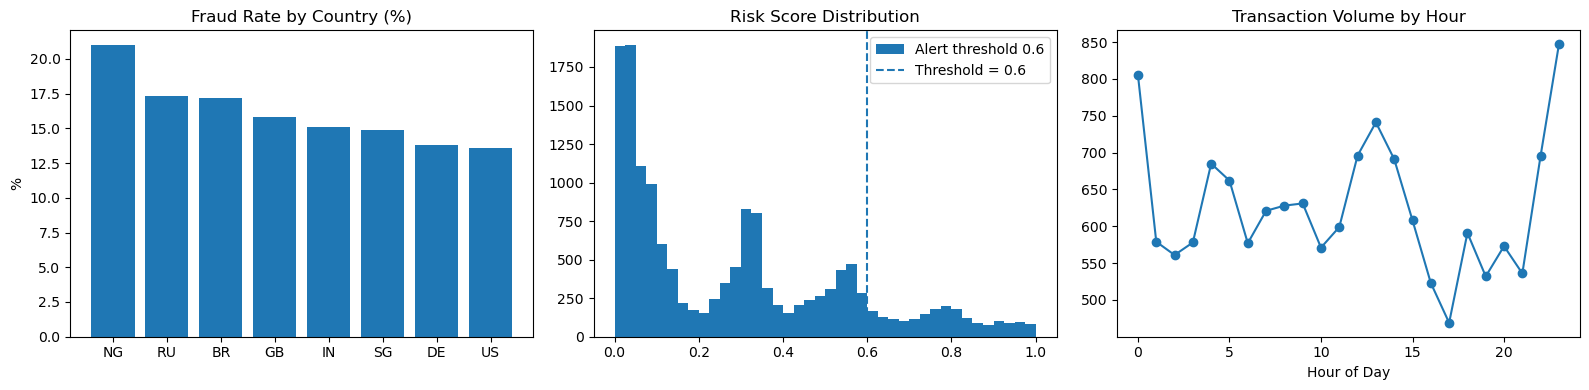

2026-09-08 23:33:59,506 | INFO | Rendered risk dashboard


In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Fraud rate by country
by_country = pd.read_sql("""
    SELECT txn_country,
           ROUND(AVG(is_fraud) * 100, 1) AS fraud_pct
    FROM fct_transaction
    GROUP BY txn_country
    ORDER BY fraud_pct DESC
""", con)

axes[0].bar(
    by_country["txn_country"],
    by_country["fraud_pct"]
)
axes[0].set_title("Fraud Rate by Country (%)")
axes[0].set_ylabel("%")

# 2. Risk score distribution
axes[1].hist(
    feat["risk_score"],
    bins=40,
    label=f"Alert threshold {RISK_THRESHOLD}"
)
axes[1].axvline(
    RISK_THRESHOLD,
    linestyle="--",
    label=f"Threshold = {RISK_THRESHOLD}"
)
axes[1].set_title("Risk Score Distribution")
axes[1].legend()

# 3. Transaction volume by hour
by_hour = feat.groupby("hour")["transaction_id"].count()

axes[2].plot(
    by_hour.index,
    by_hour.values,
    marker="o"
)
axes[2].set_title("Transaction Volume by Hour")
axes[2].set_xlabel("Hour of Day")

plt.tight_layout()
plt.show()

logger.info("Rendered risk dashboard")

In [38]:
print("=== PIPELINE HEALTH ===")
print(f"Transactions ingested : {pd.read_sql('SELECT COUNT(*) n FROM fct_transaction', con)['n'][0]:,}")
print(f"Customers (dim)        : {pd.read_sql('SELECT COUNT(*) n FROM dim_customer', con)['n'][0]:,}")
print(f"Risk alerts raised     : {pd.read_sql('SELECT COUNT(*) n FROM fct_risk_alerts', con)['n'][0]:,}")
print(f"Model ROC-AUC          : {auc:.3f}")
print("\n=== LAST 15 LOG LINES ===")
print("".join(open('pipeline.log').readlines()[-15:]))

=== PIPELINE HEALTH ===
Transactions ingested : 15,000
Customers (dim)        : 200
Risk alerts raised     : 1,986
Model ROC-AUC          : 0.860

=== LAST 15 LOG LINES ===
2026-09-08 23:30:43,461 | INFO | NL query: What are the top 5 merchant categories by fraud rate?
2026-09-08 23:30:44,968 | ERROR | LLM SQL generation failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
2026-09-08 23:30:44,985 | INFO | NL query: How many high-risk alerts came from new accounts making foreign transactions?
2026-09-08 23:32:14,484 | ERROR | Explanation failed: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
2026-09-08 23:32:14,526 | INFO | NL query: What is the total transaction value and fraud rate per countr

---
## Ask your own questions
Type any analytics question about the transaction data. The LLM will write SQL, the safety gate will check it, the warehouse will answer it, and the LLM will explain the result.


In [39]:
# Try your own — e.g. "which channel has the highest average transaction amount?"
answer_question("Which merchant category has the highest total transaction value?")

2026-09-08 23:33:59,640 | INFO | NL query: Which merchant category has the highest total transaction value?


Generated SQL:
 SELECT
  dm.category
FROM fct_transaction AS ft
JOIN dim_merchant AS dm
  ON ft.merchant_id = dm.merchant_id
GROUP BY
  dm.category
ORDER BY
  SUM(ft.amount) DESC
LIMIT 1; 

   category
electronics 

Explanation: The data indicates that the "electronics" category has the highest total transaction value. This suggests that consumers are spending the most money on electronic goods compared to other categories. Businesses in the electronics sector might benefit from understanding what specific products are driving this high value, while those in other categories may need to explore strategies to increase their transaction volumes or average transaction values.


,category
0,electronics
